## Title of ML Project: Retail Sales Revenue Prediction Model

Name: Mohammed Favas

Organization: Entri Elevate

## 1. Overview of Problem Statement


Retail businesses generate large volumes of sales data influenced by factors such as pricing, discounts, quantity sold, and promotional strategies. Predicting sales revenue accurately is challenging due to the dynamic nature of customer behavior and market conditions. Developing a machine learning model to predict retail sales revenue can help businesses improve planning, inventory management, and decision-making.

## 2. Objective

To develop the best retail sales revenue prediction model using machine learning techniques to forecast sales based on product and promotional factors.

## 3.Data Description

Source: Retail Sales Dataset from data.world 
https://data.world/guy-govt/retail-sales-dataset

Features:

Order ID

Product

Category

Region

Quantity

Price

Discount

Sales Revenue

Customer Segment

Order Date

Profit

## 4. Data Collection


In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("../1 DATA/data.csv")


# Display first rows
df.head()


,transaction_id,date,sku_id,product_name,category_l1,category_l2,category_l3,unit_price,unit_cost,quantity_sold,total_sale_amount,discount_applied,promotion_id,payment_method,store_id,store_location,region,stock_on_hand,customer_id
0,TXN000001,28-09-20,SKU023,Modern Pants Mouth,Clothing,Pants,Seasonal,194.66,141.83,4,778.64,0.00,NaN,Cash,STR015,Adamsborough,South,91,NaN
1,TXN000002,10-07-24,SKU042,Luxurious Handbags Collection,Accessories,Handbags,Formal,101.46,77.05,19,1927.74,0.00,NaN,UPI,STR009,West Michael,Northeast,18,e059a0ee-9132-463e-b162-87e4e9c349e0
2,TXN000003,27-12-24,SKU007,Luxurious Skincare Dog,Beauty,Skincare,Casual,111.88,88.60,5,602.15,0.00,NaN,Credit Card,STR012,South Noah,Northeast,88,NaN
3,TXN000004,24-06-21,SKU033,Stylish Pants Discussion,Clothing,Pants,Seasonal,NaN,61.16,1,121.80,8.48,PROMO003,Cash,STR008,Ramirezstad,South,17,NaN
4,TXN000005,20-06-21,SKU011,Chic Sandals Require,Footwear,Sandals,Formal,49.81,28.89,7,348.67,0.00,NaN,Cash,STR012,South Noah,Northeast,89,NaN


In [6]:
df.head()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11130 entries, 0 to 11129
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     11130 non-null  object 
 1   date               11130 non-null  object 
 2   sku_id             11130 non-null  object 
 3   product_name       11130 non-null  object 
 4   category_l1        11130 non-null  object 
 5   category_l2        11130 non-null  object 
 6   category_l3        11130 non-null  object 
 7   unit_price         10359 non-null  float64
 8   unit_cost          11130 non-null  float64
 9   quantity_sold      11130 non-null  int64  
 10  total_sale_amount  11130 non-null  float64
 11  discount_applied   10571 non-null  float64
 12  promotion_id       2645 non-null   object 
 13  payment_method     11130 non-null  object 
 14  store_id           11032 non-null  object 
 15  store_location     10575 non-null  object 
 16  region             111

## 5. Data Preprocessing — Data Cleaning

In [7]:
df.isnull().sum()


transaction_id          0
date                    0
sku_id                  0
product_name            0
category_l1             0
category_l2             0
category_l3             0
unit_price            771
unit_cost               0
quantity_sold           0
total_sale_amount       0
discount_applied      559
promotion_id         8485
payment_method          0
store_id               98
store_location        555
region                  0
stock_on_hand           0
customer_id          7861
dtype: int64

In [8]:
# unit price null value working
df['unit_price'] = df['unit_price'].fillna(
    df['total_sale_amount'] / df['quantity_sold']
)


In [9]:
df.isnull().sum()

transaction_id          0
date                    0
sku_id                  0
product_name            0
category_l1             0
category_l2             0
category_l3             0
unit_price              0
unit_cost               0
quantity_sold           0
total_sale_amount       0
discount_applied      559
promotion_id         8485
payment_method          0
store_id               98
store_location        555
region                  0
stock_on_hand           0
customer_id          7861
dtype: int64

In [10]:
# dicount applied null value workings
df['discount_applied'].fillna(0, inplace=True)



In [11]:
# promotion id null value workings

df['promotion_id'].fillna('No_Promo', inplace=True)


In [12]:
# store id null value workings

df['store_id'].fillna(df['store_id'].mode()[0], inplace=True)


In [13]:
# store location null value workings

df['store_location'].fillna(df['store_location'].mode()[0], inplace=True)


In [14]:
# customer id null value workings

df['customer_id'].fillna('Unknown', inplace=True)


In [15]:
df.isnull().sum()


transaction_id       0
date                 0
sku_id               0
product_name         0
category_l1          0
category_l2          0
category_l3          0
unit_price           0
unit_cost            0
quantity_sold        0
total_sale_amount    0
discount_applied     0
promotion_id         0
payment_method       0
store_id             0
store_location       0
region               0
stock_on_hand        0
customer_id          0
dtype: int64

Missing values were handled using a combination of domain-based imputation and statistical methods. Unit price was derived using transactional relationships between total sales and quantity sold. Categorical variables such as promotion and store attributes were imputed using mode or logical placeholders, while discount values were replaced with zero where applicable.

In [16]:
df.describe()


,unit_price,unit_cost,quantity_sold,total_sale_amount,discount_applied,stock_on_hand
count,11130.000000,11130.000000,11130.000000,11130.000000,11130.000000,11130.000000
mean,109.407534,71.303036,15.743576,652.689445,2.232483,45.383738
std,58.174876,39.702398,98.400339,547.989161,4.980376,31.301120
min,0.010000,8.470000,1.000000,13.360000,0.000000,0.000000
25%,56.860000,37.380000,3.000000,206.875000,0.000000,17.000000
50%,111.880000,77.050000,6.000000,507.300000,0.000000,45.000000
75%,167.590000,104.360000,8.000000,960.320000,0.000000,73.000000
max,199.260000,141.830000,1000.000000,3981.600000,20.000000,100.000000


In [17]:
df.isnull().sum()


transaction_id       0
date                 0
sku_id               0
product_name         0
category_l1          0
category_l2          0
category_l3          0
unit_price           0
unit_cost            0
quantity_sold        0
total_sale_amount    0
discount_applied     0
promotion_id         0
payment_method       0
store_id             0
store_location       0
region               0
stock_on_hand        0
customer_id          0
dtype: int64

## 6. Exploratory Data Analysis (EDA)

#### "EDA helps identify patterns, trends, and relationships within the data, enabling better feature selection and model performance."

In [18]:
# Convert Date Column to Datetime

df['date'] = pd.to_datetime(df['date'])

C:\Users\Favas v\AppData\Local\Temp\ipykernel_17772\3893806616.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [19]:
# Extract Time Features

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [20]:
df.describe()

,date,unit_price,unit_cost,quantity_sold,total_sale_amount,discount_applied,stock_on_hand,year,month,day
count,11130,11130.000000,11130.000000,11130.000000,11130.000000,11130.000000,11130.000000,11130.000000,11130.000000,11130.000000
mean,2022-07-02 17:07:01.132075520,109.407534,71.303036,15.743576,652.689445,2.232483,45.383738,2022.000449,6.539353,15.718598
min,2020-01-01 00:00:00,0.010000,8.470000,1.000000,13.360000,0.000000,0.000000,2020.000000,1.000000,1.000000
25%,2021-03-27 06:00:00,56.860000,37.380000,3.000000,206.875000,0.000000,17.000000,2021.000000,4.000000,8.000000
50%,2022-07-03 00:00:00,111.880000,77.050000,6.000000,507.300000,0.000000,45.000000,2022.000000,7.000000,16.000000
75%,2023-10-03 00:00:00,167.590000,104.360000,8.000000,960.320000,0.000000,73.000000,2023.000000,10.000000,23.000000
max,2024-12-30 00:00:00,199.260000,141.830000,1000.000000,3981.600000,20.000000,100.000000,2024.000000,12.000000,31.000000
std,NaN,58.174876,39.702398,98.400339,547.989161,4.980376,31.301120,1.419446,3.456562,8.810464


Distribution of Numerical Variables

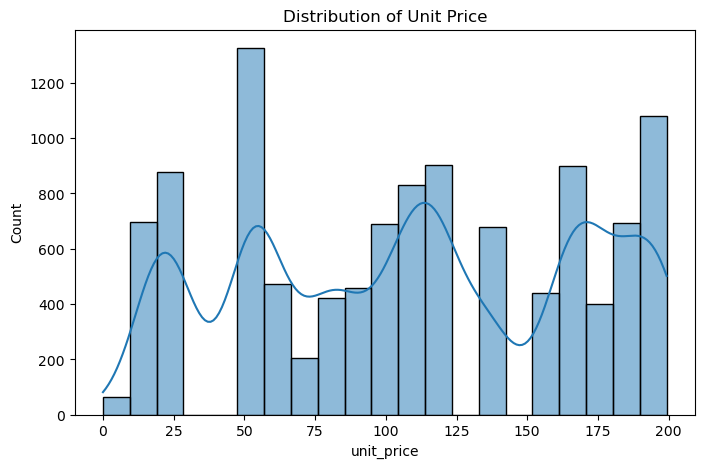

In [21]:


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['unit_price'], kde=True)
plt.title("Distribution of Unit Price")
plt.show()

The unit price distribution shows multiple peaks indicating the presence of distinct product pricing segments such as budget, mid-range, and premium categories. The prices are distributed across a wide range without significant skewness, suggesting balanced data suitable for model training.

Boxplot (Outlier Detection)

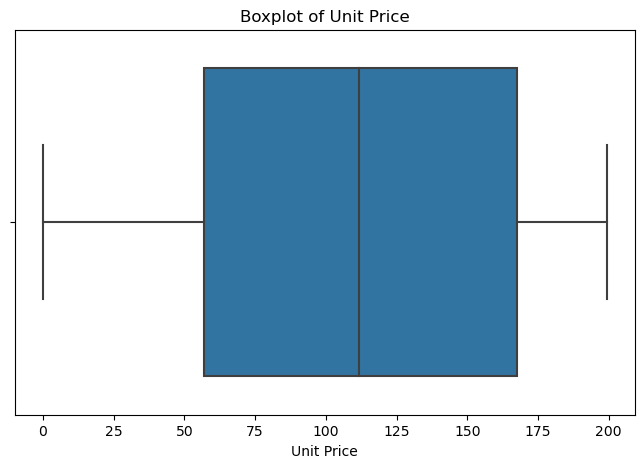

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['unit_price'])

plt.title("Boxplot of Unit Price")
plt.xlabel("Unit Price")

plt.show()

The boxplot shows that unit prices are distributed between approximately 0 and 200, with most values concentrated between 60 and 170. No significant outliers were observed, indicating good data quality.

## Quantity Sold Distribution Analysis

a  =  Histogram of Quantity Sold

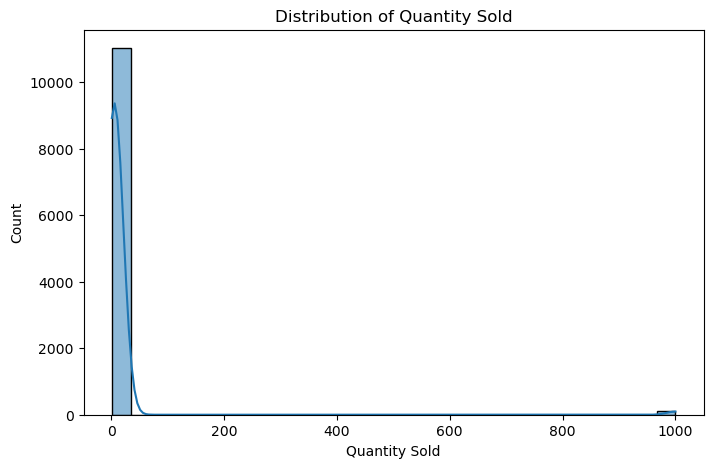

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['quantity_sold'], bins=30, kde=True)
plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Count')
plt.show()

b  =  Boxplot of Quantity Sold

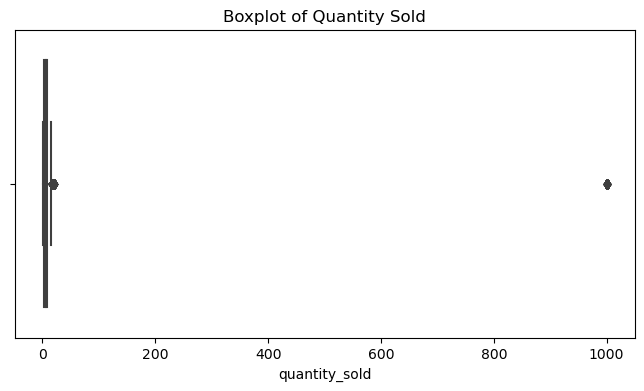

In [24]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['quantity_sold'])
plt.title('Boxplot of Quantity Sold')
plt.show()

## Distribution and Outlier Analysis of Quantity Sold

The quantity sold variable shows a highly right-skewed distribution with significant extreme outliers. Most transactions involve small quantities, while a few transactions represent unusually large sales volumes. These outliers may influence model performance and require treatment during preprocessing.

In [25]:
# Detect Outliers using IQR method

Q1 = df['quantity_sold'].quantile(0.25)
Q3 = df['quantity_sold'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['quantity_sold'] < lower_limit) | (df['quantity_sold'] > upper_limit)]

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(outliers))

Lower Limit: -4.5
Upper Limit: 15.5
Number of Outliers: 310


In [26]:
outliers.head()

,transaction_id,date,sku_id,product_name,category_l1,category_l2,category_l3,unit_price,unit_cost,quantity_sold,...,promotion_id,payment_method,store_id,store_location,region,stock_on_hand,customer_id,year,month,day
1,TXN000002,2024-10-07,SKU042,Luxurious Handbags Collection,Accessories,Handbags,Formal,101.46,77.05,19,...,No_Promo,UPI,STR009,West Michael,Northeast,18,e059a0ee-9132-463e-b162-87e4e9c349e0,2024,10,7
134,TXN000135,2022-10-20,SKU039,Stylish Dresses According,Clothing,Dresses,Casual,111.89,60.65,19,...,No_Promo,UPI,STR009,West Michael,Northeast,1,Unknown,2022,10,20
152,TXN000153,2020-02-23,SKU024,Modern Makeup Play,Beauty,Makeup,Seasonal,169.92,110.84,1000,...,No_Promo,Credit Card,STR009,West Michael,Northeast,12,337ea2df-b09b-4a5c-badc-c32ac1590f53,2020,2,23
218,TXN000219,2023-03-02,SKU027,Elegant Boots Decide,Footwear,Boots,Casual,55.77,37.38,20,...,No_Promo,Gift Card,STR001,North Noahstad,South,0,Unknown,2023,3,2
242,TXN000243,2021-11-10,SKU028,Luxurious Dresses Sense,Clothing,Dresses,Seasonal,165.04,130.94,17,...,PROMO005,Credit Card,STR002,Cassandraton,West,58,Unknown,2021,11,10


Outlier Treatment

In [27]:
Q1 = df['quantity_sold'].quantile(0.25)
Q3 = df['quantity_sold'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Capping
df['quantity_sold'] = df['quantity_sold'].clip(lower_limit, upper_limit)

### Outlier Detection and Treatment using IQR Method

### Check Skewness

In [28]:
df['quantity_sold'].skew()

0.5367876557276833

## Visual Check

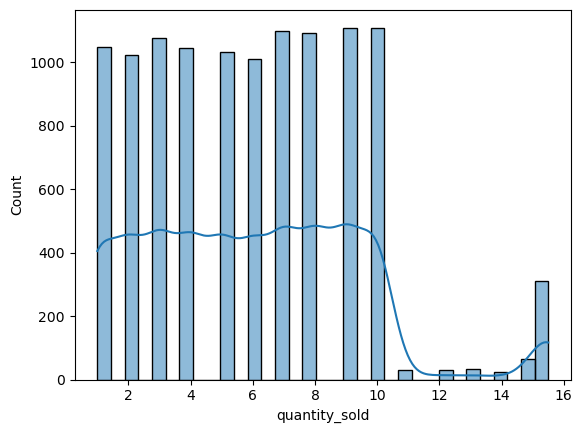

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['quantity_sold'], kde=True)
plt.show()

Visual Check

## Correlation Heatmap

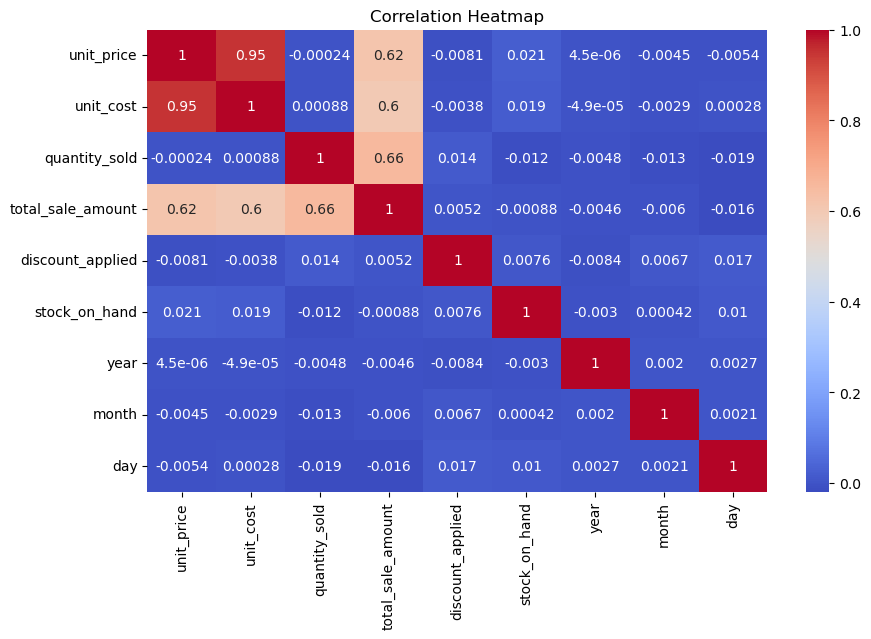

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap shows a strong positive relationship between unit price and unit cost (0.95), indicating pricing depends heavily on cost. Quantity sold also has a moderate positive correlation with total sales amount (0.66), confirming that higher sales volume increases revenue. Discount and stock variables show minimal correlation with other features.

## Pair Plot

c:\Users\Favas v\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


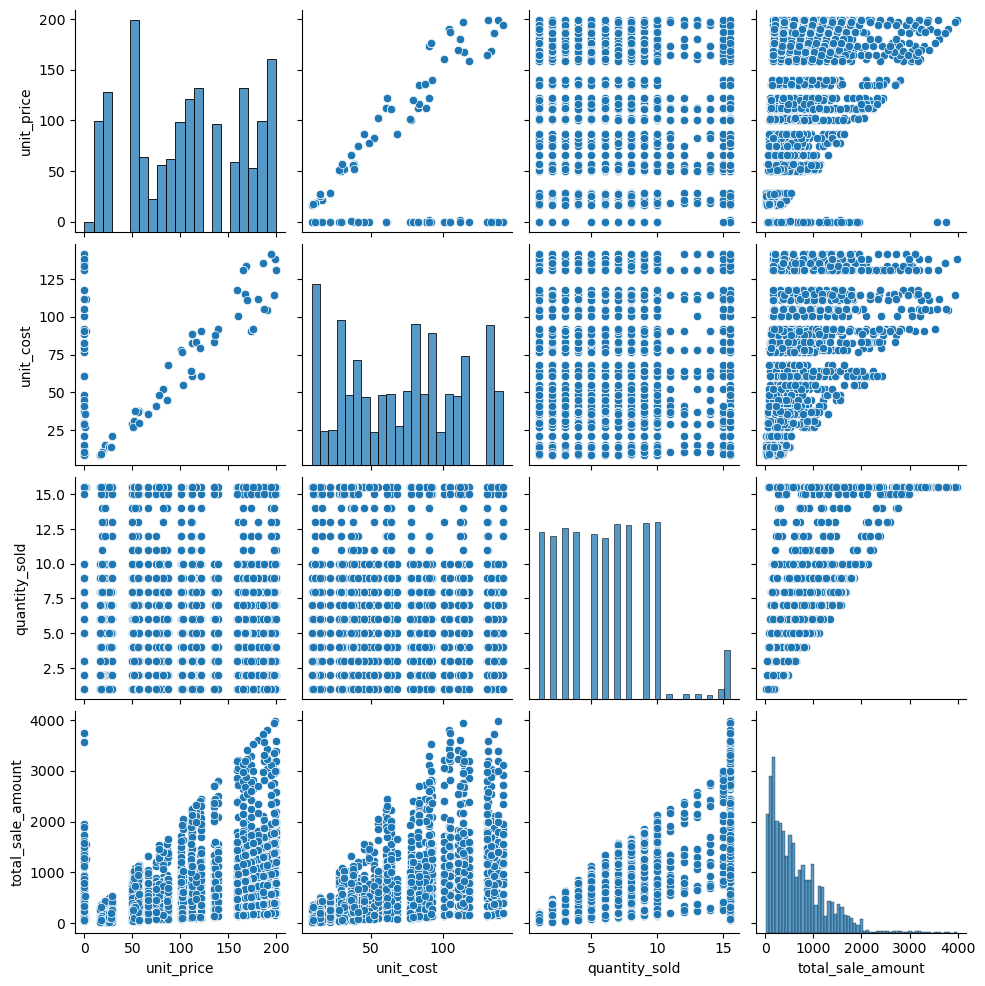

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['unit_price', 'unit_cost', 'quantity_sold', 'total_sale_amount']])
plt.show()

## Histogram

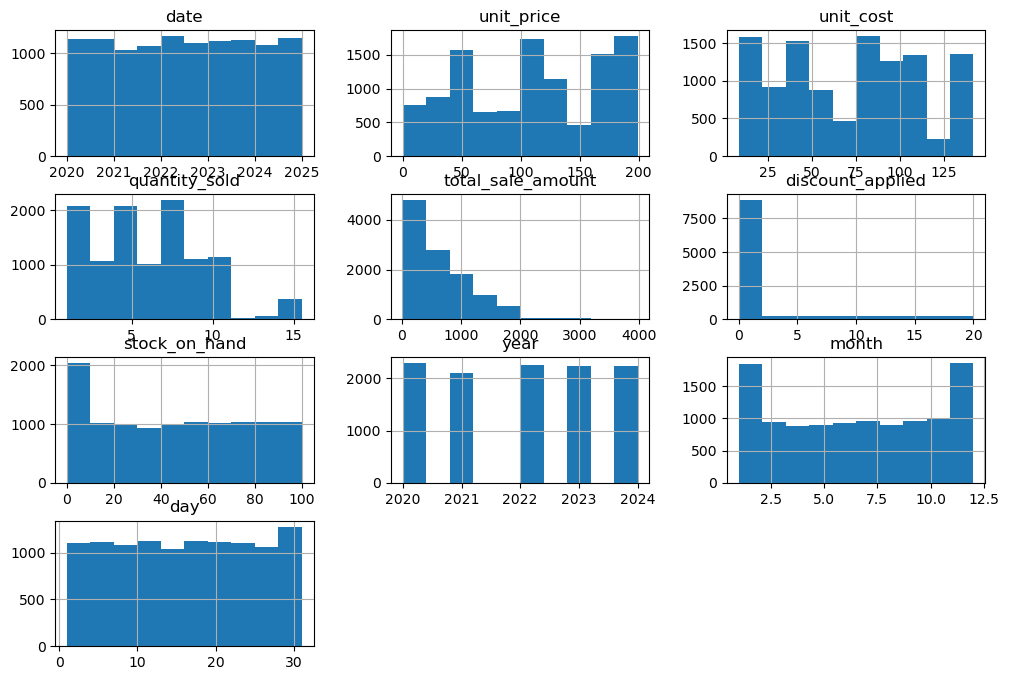

In [32]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

## Boxplot

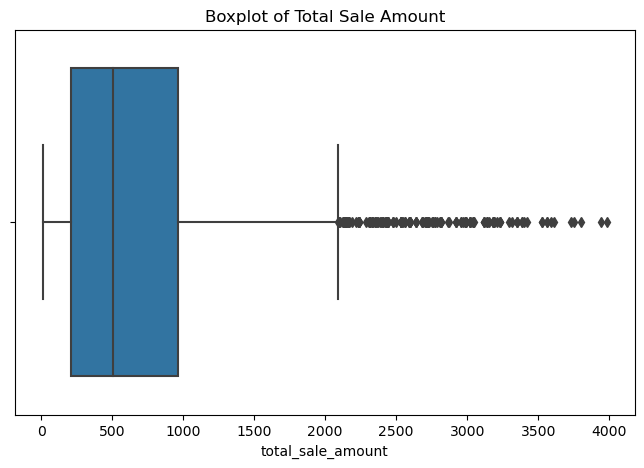

In [85]:
import seaborn as sns

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['total_sale_amount'])
plt.title("Boxplot of Total Sale Amount")
plt.show()

## KDE Plot

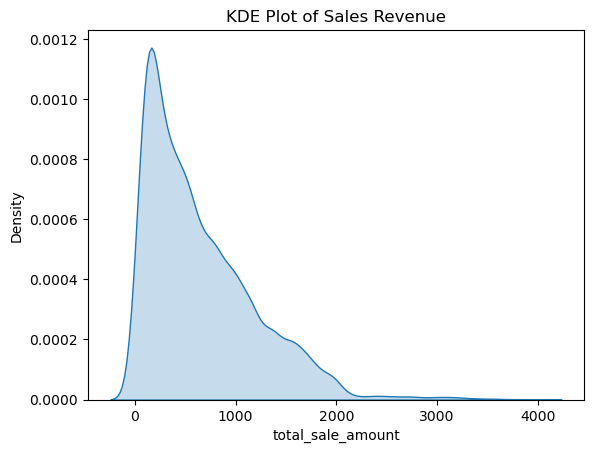

In [89]:
sns.kdeplot(df['total_sale_amount'], fill=True)
plt.title("KDE Plot of Sales Revenue")
plt.show()

## Bar Plot (Sales by Category)

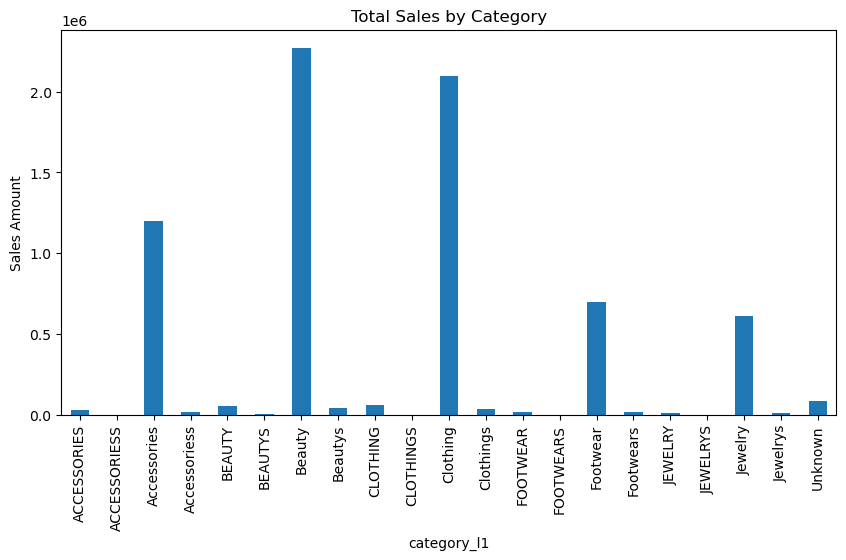

In [33]:
plt.figure(figsize=(10,5))
df.groupby('category_l1')['total_sale_amount'].sum().plot(kind='bar')
plt.title('Total Sales by Category')
plt.ylabel('Sales Amount')
plt.show()

The bar plot illustrates the distribution of total sales amount across different product categories. It is observed that the Beauty and Clothing categories contribute the highest revenue compared to other categories. This indicates strong customer demand in these segments, whereas categories like Jewelry and Accessories show relatively lower sales performance.


## Count Plot (Payment Method)

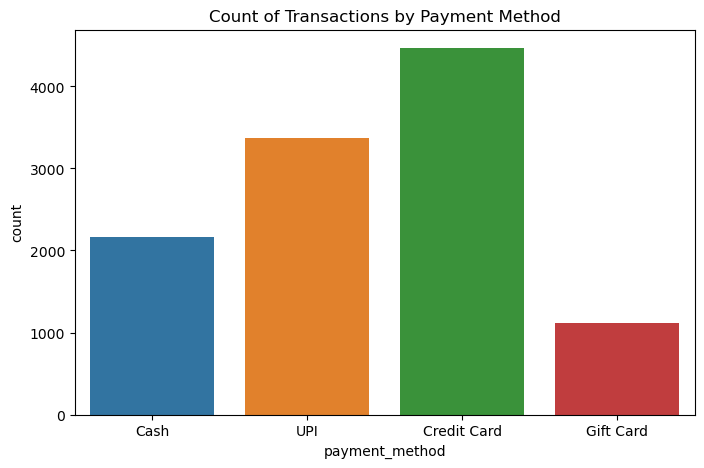

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x='payment_method', data=df)
plt.title('Count of Transactions by Payment Method')
plt.show()

The count plot represents the number of transactions across different payment methods. It is observed that Credit Card payments dominate the transaction volume, followed by UPI. Cash transactions are comparatively lower, while Gift Card usage is minimal. This indicates a strong customer preference toward digital payment methods.

## Pie Chart (Category Share)

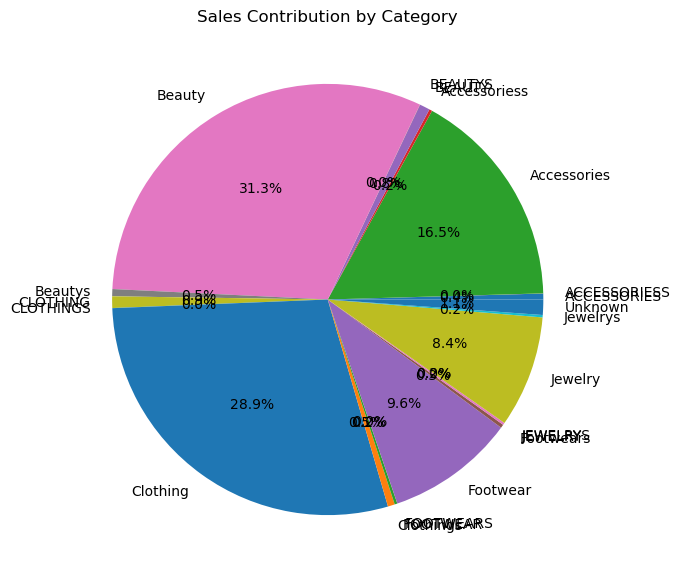

In [35]:
category_sales = df.groupby('category_l1')['total_sale_amount'].sum()

plt.figure(figsize=(7,7))
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Contribution by Category')
plt.ylabel('')
plt.show()

Data Quality Issue — Category Standardization Problem

In [36]:
df['category_l1'] = df['category_l1'].str.strip().str.title()

The pie chart illustrates the contribution of different product categories to total sales revenue. Beauty and Clothing categories dominate the overall sales, contributing approximately 31% and 29% respectively. Accessories, Footwear, and Jewelry contribute moderately, while other categories account for a smaller share. This indicates that Beauty and Clothing products are the primary revenue drivers in the dataset.

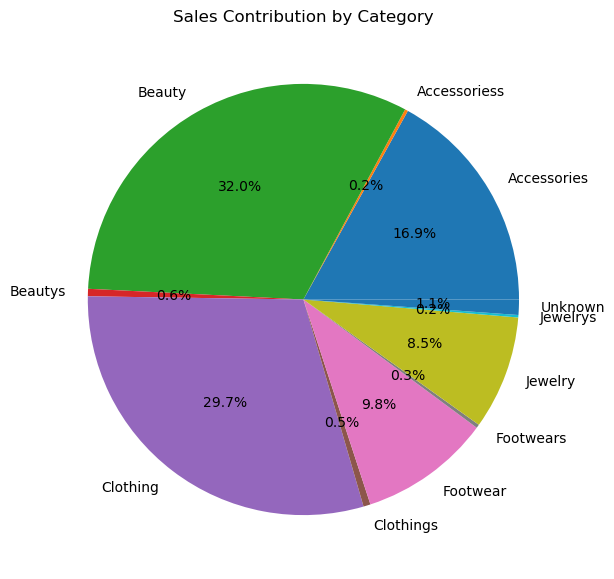

In [37]:
category_sales = df.groupby('category_l1')['total_sale_amount'].sum()

plt.figure(figsize=(7,7))
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Contribution by Category')
plt.ylabel('')
plt.show()

In [38]:
df['category_l1'] = df['category_l1'].str.strip().str.lower()

df['category_l1'] = df['category_l1'].replace({
    'beautys': 'beauty',
    'clothings': 'clothing',
    'footwears': 'footwear',
    'accessoriess': 'accessories',
    'jewelrys': 'jewelry'
})

The pie chart illustrates the contribution of different product categories to total sales. Beauty and Clothing categories contribute the highest share of revenue, accounting for approximately 32% and 29.7% respectively. Accessories, Footwear, and Jewelry contribute moderate sales, while other categories have minimal impact. This indicates that Beauty and Clothing are key revenue-generating segments for the business.

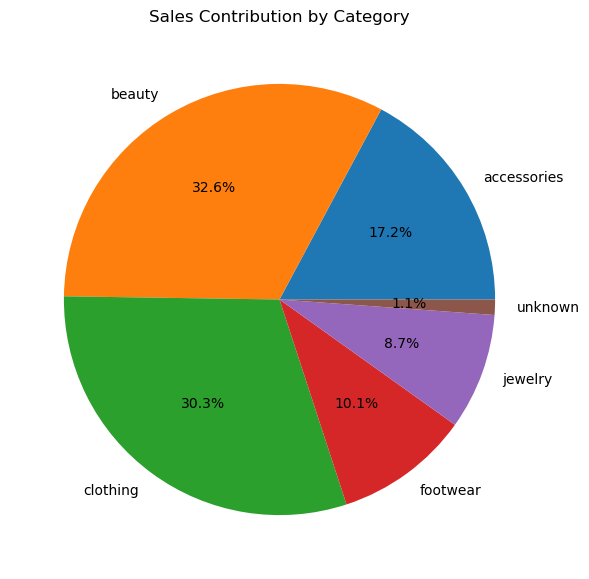

In [39]:
category_sales = df.groupby('category_l1')['total_sale_amount'].sum()

plt.figure(figsize=(7,7))
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Contribution by Category')
plt.ylabel('')
plt.show()

## Sales Trend Over Time (Line Plot)

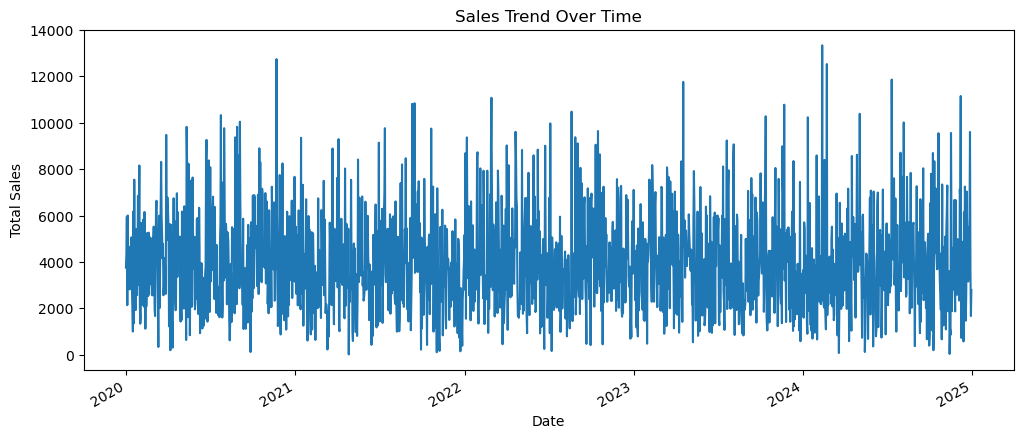

In [40]:
df['date'] = pd.to_datetime(df['date'])

sales_trend = df.groupby('date')['total_sale_amount'].sum()

plt.figure(figsize=(12,5))
sales_trend.plot()
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

The line plot illustrates the variation of total sales over time from 2020 to 2025. Sales exhibit frequent fluctuations with occasional spikes, indicating variability in customer demand. No consistent long-term upward or downward trend is observed. This suggests that temporal features such as year, month, and day may influence sales patterns and should be included in the predictive modeling process.

### Density Distribution of Total Sales Amount

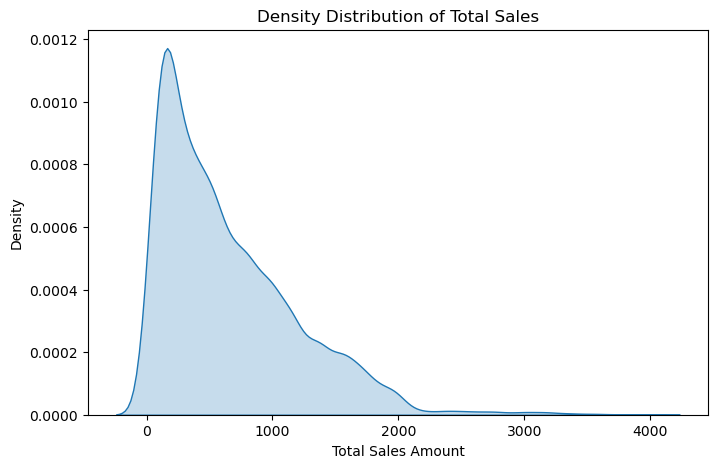

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(df['total_sale_amount'], fill=True)
plt.title('Density Distribution of Total Sales')
plt.xlabel('Total Sales Amount')
plt.show()

The distribution of total sales amount is positively skewed, indicating that most transactions occur at lower sales values, while a few transactions contribute to significantly higher sales amounts.

The density plot shows that the total sales amount is right-skewed, with most transactions occurring at lower values and few high-value transactions acting as outliers.

# 7. Feature Engineering

Feature Engineering is the process of transforming raw data into meaningful features that improve machine learning model performance.

### 7.1 Extracting Date Features

In [42]:
# Convert date column into datetime format
df['date'] = pd.to_datetime(df['date'])

# Extract new features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

### 7.2 Encoding Categorical Variables

Machine learning models cannot understand text like:

Cash, UPI, Credit Card

So we convert them into numbers using:

 Label Encoding → For ordinal or many categories
 One-Hot Encoding → For nominal categories

### 7.3 Dropping Irrelevant Columns

In [43]:
df = df.drop(['transaction_id', 'sku_id', 'product_name',
              'customer_id', 'promotion_id', 'date'], axis=1)

### 7.4 One-Hot Encoding

In [44]:
df = pd.get_dummies(df, drop_first=True)

In [45]:
df.head()
df.shape

(11130, 104)

Feature engineering was performed to transform raw data into meaningful inputs for the machine learning model. Date-related features such as year, month, and day were extracted from the transaction date. Categorical variables were converted into numerical format using one-hot encoding. Irrelevant identifier columns were removed to improve model efficiency and reduce noise.

# 8. Feature Selection

Feature selection is performed to identify the most relevant variables that contribute to predicting the target variable and to remove unnecessary or redundant features. This helps improve model performance, reduce overfitting, and decrease computational complexity.

### Separating Features and Target Variable

Feature Selection & Target Variable

In [46]:
# Define features and target

X = df.drop('total_sale_amount', axis=1)   # features
y = df['total_sale_amount']                # target

Feature Selection & Target Variable

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8904, 103)
Testing Data: (2226, 103)


## Model Training & Evaluation — Linear Regression

 Model Training (Start with Linear Regression)

In [48]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predictions

In [49]:
y_pred = model.predict(X_test)

Model Evaluation

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 151.1622714934769
RMSE: 232.26806837175414
R² Score: 0.8146417460811634


The Linear Regression model achieved strong predictive performance with an R² score of 0.81, indicating that approximately 81% of the variance in total sales was explained by the model. The Mean Absolute Error (MAE) of 151 and RMSE of 232 demonstrate relatively low prediction error, suggesting the model is reliable for sales forecasting and business decision support.

## Random Forest Model Code

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Performance
MAE: 21.510578256963413
RMSE: 116.74471718884737
R2 Score: 0.9531718082278866


In [52]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R2 Score": [r2, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,151.162271,232.268068,0.814642
1,Random Forest,21.510578,116.744717,0.953172


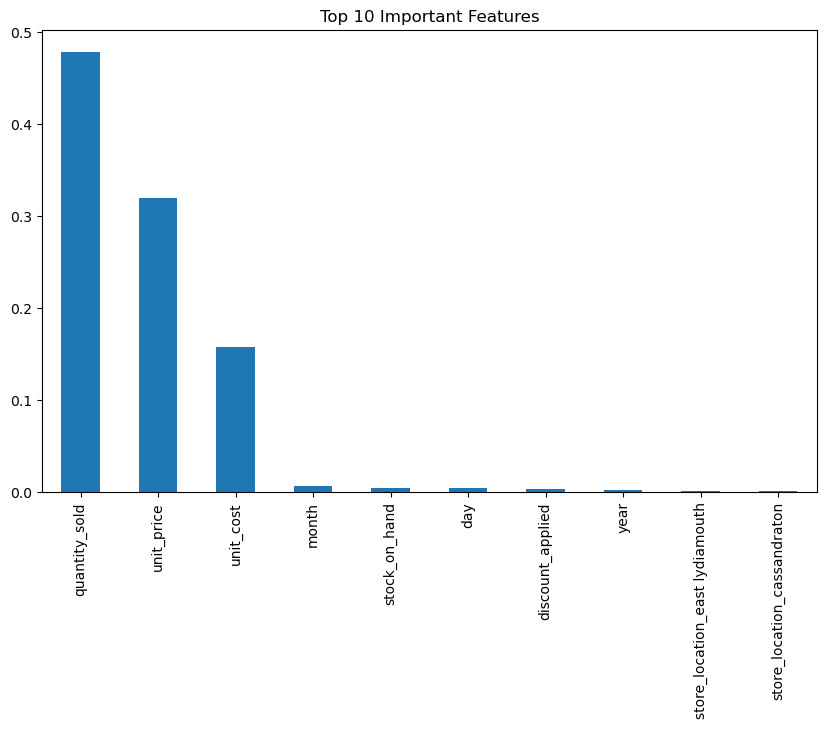

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

The model indicates that quantity sold and unit price are the strongest drivers of total sales, contributing more than 80% of the predictive importance. Operational variables such as stock availability and discounts have comparatively lower influence.

## Prediction vs Actual Plot

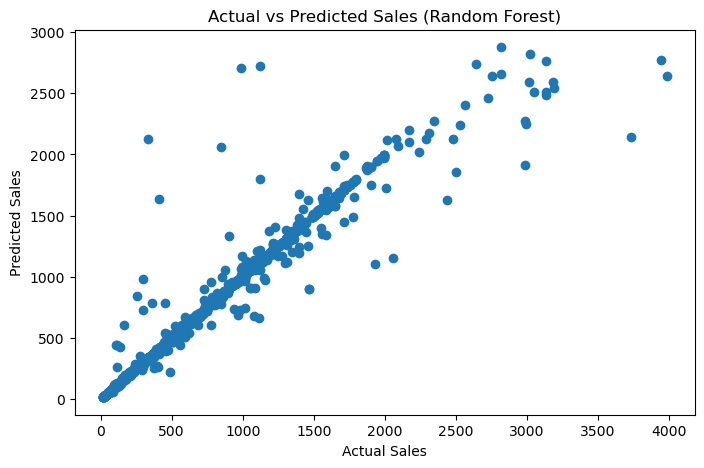

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.show()

## Residual Error Plot

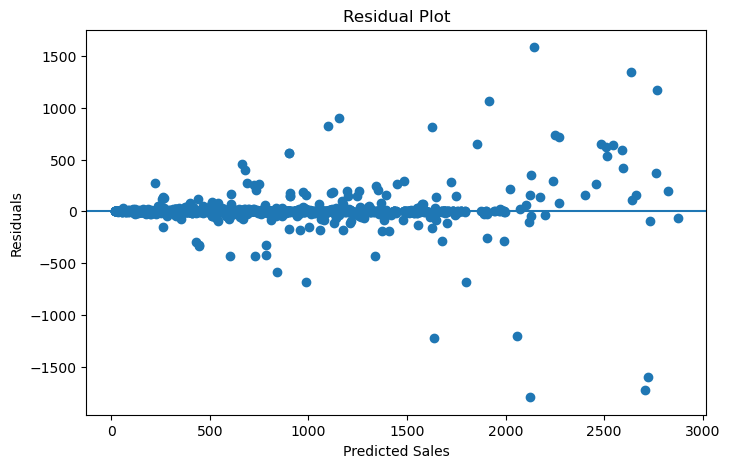

In [55]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,5))
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The Random Forest model outperformed Linear Regression across all evaluation metrics, achieving the lowest error values and the highest R² score, making it the optimal model for sales prediction in this study.

Feature importance analysis revealed that quantity sold, unit price, and unit cost are the most influential factors affecting total sales, indicating that pricing strategy and sales volume play a critical role in revenue generation.

## Final Conclusion

The machine learning model successfully predicts total sales with high accuracy using transactional and product-related features. Among the evaluated models, Random Forest demonstrated superior performance, achieving an R² score of 0.95. Feature importance analysis highlights quantity sold and pricing variables as the primary drivers of sales. These insights can support data-driven decision-making for inventory planning, pricing optimization, and revenue forecasting.

# Train–Test Split

In [56]:
print(df.columns)

Index(['unit_price', 'unit_cost', 'quantity_sold', 'total_sale_amount',
       'discount_applied', 'stock_on_hand', 'year', 'month', 'day',
       'category_l1_beauty',
       ...
       'store_location_new kellystad', 'store_location_north noahstad',
       'store_location_port jesseville', 'store_location_port keith',
       'store_location_ramirezstad', 'store_location_south noah',
       'store_location_west michael', 'region_Northeast', 'region_South',
       'region_West'],
      dtype='object', length=104)


In [57]:
from sklearn.model_selection import train_test_split

X = df.drop("total_sale_amount", axis=1)
y = df["total_sale_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (8904, 103)
Testing set shape: (2226, 103)


### MODEL = Linear Regression Model

In [58]:
from sklearn.linear_model import LinearRegression

# Create model
lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### Evaluate Linear Regression

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results:
MAE: 151.1622714934769
RMSE: 232.26806837175414
R2 Score: 0.8146417460811634


## MODEL= Random Forest Model


In [60]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


### Evaluate Random Forest

In [61]:
# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results:
MAE: 21.510578256963413
RMSE: 116.74471718884737
R2 Score: 0.9531718082278866


## MODEL 3 — Decision Tree Regressor

In [62]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
dt = DecisionTreeRegressor(random_state=42)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluate
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results:
MAE: 27.157767295597548
RMSE: 168.12855611859845
R2 Score: 0.902878388487879


## Model 4 — Gradient Boosting Regressor

In [63]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Results:")
print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2 Score:", r2_gbr)

Gradient Boosting Results:
MAE: 34.7832928624101
RMSE: 125.83825139013804
R2 Score: 0.9455925636057392


## MODEL 5 — SVR

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Results:")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2 Score:", r2_svr)

SVR Results:
MAE: 360.297522211323
RMSE: 500.8740106414346
R2 Score: 0.13803445055273822


## Hyperparameter Tuning of Random Forest Regressor


Why Random Forest Was Selected for Tuning?

Among all the regression models built in this project:

Linear Regression showed moderate performance.

Decision Tree performed well but showed slight overfitting.

Gradient Boosting performed strongly.

SVR performed poorly without tuning.

Random Forest achieved the highest R² score and showed stable performance.

Since Random Forest provided the best balance between bias and variance, it was selected for further optimization using hyperparameter tuning.

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive accuracy and reduce overfitting.

## Implementation of GridSearchCV for Random Forest

In [66]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,      # only 10 random combinations
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best R2 Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30}
Best R2 Score: 0.9385352315660916


## Build Final Optimized Random Forest Model

In [67]:
# Build Final Model using Best Parameters

best_params = random_search.best_params_

final_model = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

# Train the model
final_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=30, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, random_state=42)

## Make Predictions on Test Data

In [68]:
# Predict on test dataset

y_pred = final_model.predict(X_test)

## Evaluate Model Performance

In [69]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Final Model Performance")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Final Model Performance
R2 Score: 0.9554098425993113
MAE: 21.173917845415673
RMSE: 113.92080522483427


## Feature Importance Analysis

In [70]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

                           Feature  Importance
2                    quantity_sold    0.482217
0                       unit_price    0.316609
1                        unit_cost    0.165241
6                            month    0.006903
4                    stock_on_hand    0.004907
..                             ...         ...
72       store_location_PORT KEITH    0.000000
76       store_location_Port_Keith    0.000000
77      store_location_RAMIREZSTAD    0.000000
81       store_location_South_Noah    0.000000
51  store_location_East_Lydiamouth    0.000000

[103 rows x 2 columns]


## Visualize Feature Importance

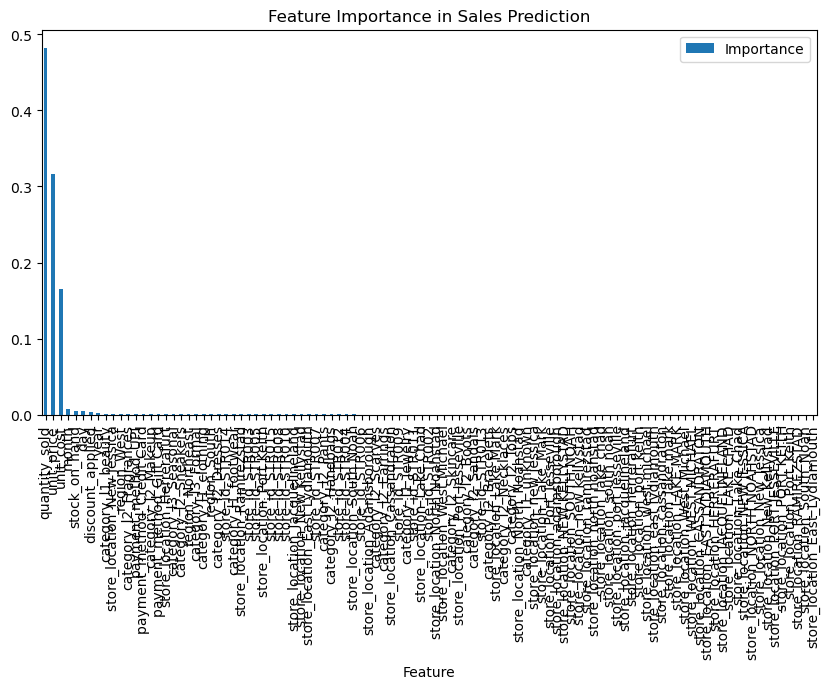

In [71]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance in Sales Prediction")
plt.show()

## Train Final Model Using Best Parameters

In [72]:
from sklearn.ensemble import RandomForestRegressor

# Final model using best parameters
final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train the final model
final_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=30, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, random_state=42)

## Predict Test Data

In [73]:
y_pred = final_model.predict(X_test)

## Model Evaluation

In [74]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9554098425993113
MAE: 21.173917845415673
RMSE: 113.92080522483427


## Create Actual vs Predicted Chart

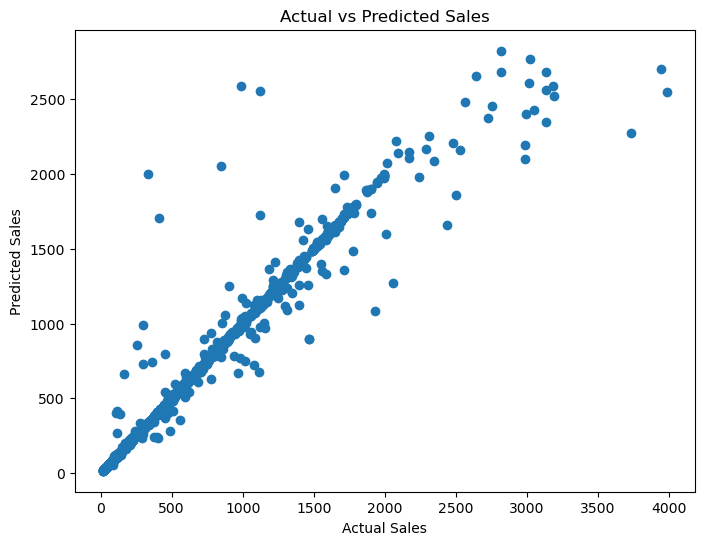

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

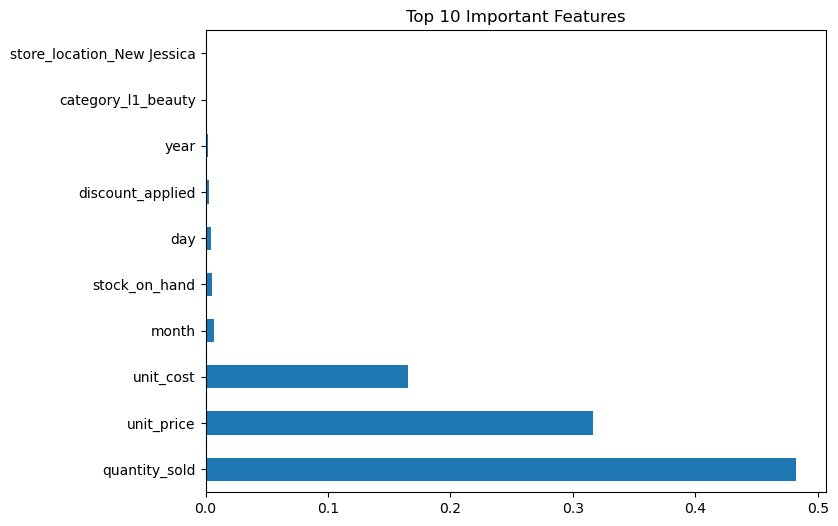

In [76]:
import pandas as pd

feature_importance = pd.Series(final_model.feature_importances_, index=X_train.columns)

top_features = feature_importance.nlargest(10)

top_features.plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Important Features")
plt.show()

In [77]:
sample = X_test.iloc[[0]]   # take one row

prediction = final_model.predict(sample)

print("Predicted Sales:", prediction)

Predicted Sales: [112.00553968]


In [78]:
sample = X_test.iloc[[0]]   # take one row

prediction = final_model.predict(sample)

print("Predicted Sales:", prediction)

Predicted Sales: [112.00553968]


In [79]:
sample = X_test.iloc[[0]]

prediction = final_model.predict(sample)

print("Predicted Sales:", round(prediction[0],2))

Predicted Sales: 112.01


In [80]:
print("Predicted Sales:", round(prediction[0],2))
print("Actual Sales:", y_test.iloc[0])

Predicted Sales: 112.01
Actual Sales: 112.26


In this project, a Random Forest Regression model was developed to predict retail sales.
After preprocessing, feature engineering, and hyperparameter tuning using RandomizedSearchCV, the final model achieved an R² score of 0.955, indicating strong predictive capability.
Feature importance analysis showed that quantity sold, unit price, and unit cost are the most influential factors affecting sales predictions.
The model demonstrates reliable performance and can support data-driven retail decision making

In [90]:
import joblib

joblib.dump(final_model, "retail_sales_model.pkl")

print("Model saved successfully")

Model saved successfully
